#**Are We Seeing Aliens or Just Watching Too Many Movies?**
###*Authors: Emna BEN AMEUR, Lélie CHENOUGA, Safia LAMRI, Nina VIVIER BARTE*

## **1. Data Import**

Execute the next piece of code, then select the following csv:

- `scrubbed.csv`
- `hollywood_scifi_movies_INTEGRAL.csv`

In [ ]:
# ============================
# STEP 1 - UPLOAD CSV FILES
# ============================

try:
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
except ImportError:
    print("Not running in Colab. Just make sure the CSVs are in the same folder as this script.")

import os

# Hardcoded filenames (easier and more standard)
ufo_file = "scrubbed.csv"
movies_file = "hollywood_scifi_movies_INTEGRAL.csv"

# Quick sanity check
if not os.path.exists(ufo_file) or not os.path.exists(movies_file):
    print("Warning: One or both CSV files are missing. Please check your folder.")
else:
    print("UFO dataset detected:", ufo_file)
    print("Movies dataset detected:", movies_file)

Saving hollywood_scifi_movies_INTEGRAL.csv to hollywood_scifi_movies_INTEGRAL (1).csv
Saving scrubbed.csv to scrubbed (1).csv
Uploaded files: ['hollywood_scifi_movies_INTEGRAL (1).csv', 'scrubbed (1).csv']
UFO dataset detected: scrubbed.csv
Movies dataset detected: hollywood_scifi_movies_INTEGRAL.csv


## **2. Library Import & General Parameters**

In [ ]:
# ============================
# STEP 2 - IMPORTS & PARAMS
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from IPython.display import display

# Pandas display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Base parameters
START_DATE = pd.Timestamp("1990-01-01")
WINDOWS_DAYS = [30, 90]  # Testing 1 month vs 3 months windows

# Movie filter: sticking to vote_count > 1000 to catch older cult classics
VOTE_COUNT_THRESHOLD = 1000

# Priors for Gamma distribution
ALPHA0 = 1.0
BETA0 = 1.0

# Monte Carlo setup
N_SIM = 100_000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## **3. Data Cleansing**




In [ ]:
ufo_raw = pd.read_csv(ufo_file, low_memory=False)
movies_raw = pd.read_csv(movies_file, low_memory=False)

print("UFO Dataset Dimensions:", ufo_raw.shape)
print("UFO Columns :")
print(list(ufo_raw.columns))

display(ufo_raw.head())

print("SFMovies Dataset Dimensions:", movies_raw.shape)
print("SFMovies Columns:")
print(list(movies_raw.columns))

display(movies_raw.head())

UFO Dataset Dimensions: (80332, 11)
UFO Columns :
['datetime', 'city', 'state', 'country', 'shape', 'duration (seconds)', 'duration (hours/min)', 'comments', 'date posted', 'latitude', 'longitude ']


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


SFMovies Dataset Dimensions: (10000, 5)
SFMovies Columns:
['title', 'release_date', 'popularity', 'vote_average', 'vote_count']


,title,release_date,popularity,vote_average,vote_count
0,War Machine,2026-03-06,472.8603,7.227,856
1,Hoppers,2026-03-06,148.4862,7.718,195
2,Greenland 2: Migration,2026-01-09,138.5129,6.432,606
3,Mercy,2026-01-23,127.8050,7.105,735
4,"Good Luck, Have Fun, Don't Die",2026-02-13,102.3336,6.978,159


### **3.1 UFO Dataset**

**Goal:** Prep a clean, US-only UFO dataset for time-series modeling.

**Cleaning steps:**
- Fix the `24:00` timestamp bug
- Parse `datetime` into standard pandas format
- Filter for US sightings only (`country == 'us'`)
- Drop duration outliers (keeping only reports between **1 sec** and **24 hours**)
- Extract `date`, `year`, and `month` features



In [ ]:
# ============================
# STEP 3.1 - UFO CLEANSING
# ============================

ufo = ufo_raw.copy()

# Clean up column names (lowercase, replace spaces, remove parentheses)
ufo.columns = (
    ufo.columns.str.strip().str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"\(|\)", "", regex=True)
)

# Fix the annoying '24:00' bug that crashes pandas to_datetime
def fix_24h(s):
    s = s.astype(str).str.strip()
    mask_24 = s.str.endswith("24:00", na=False)

    # Temp replace with 00:00, parse it, then add a day back to the affected rows
    s_fixed = s.str.replace("24:00$", "00:00", regex=True)
    dt = pd.to_datetime(s_fixed, format="%m/%d/%Y %H:%M", errors="coerce")
    dt.loc[mask_24] += pd.Timedelta(days=1)
    return dt

ufo["datetime_clean"] = fix_24h(ufo["datetime"])

# Clean up types and strings
ufo["duration_seconds"] = pd.to_numeric(ufo["duration_seconds"], errors="coerce")
ufo["country"] = ufo["country"].astype(str).str.lower().str.strip()

# Extract time features
ufo["date"] = ufo["datetime_clean"].dt.floor("D")
ufo["year"] = ufo["datetime_clean"].dt.year
ufo["month"] = ufo["datetime_clean"].dt.month
ufo["day"] = ufo["datetime_clean"].dt.day

# Apply final filters: US only, 1 sec to 24h duration, and post-1990
ufo_clean = ufo[
    (ufo["datetime_clean"].notna()) &
    (ufo["country"] == "us") &
    (ufo["duration_seconds"].between(1, 86400)) &
    (ufo["date"] >= START_DATE)
].copy()

print(f"Cleaned UFO dataset shape: {ufo_clean.shape}")
print(f"Date range: {ufo_clean['date'].min().date()} to {ufo_clean['date'].max().date()}")

display(ufo_clean.head())

Cleaned UFO dataset shape: (59974, 16)
Date range: 1990-01-03 to 2014-05-08


,datetime,city,state,country,shape,duration_seconds,duration_hours/min,comments,date_posted,latitude,longitude,datetime_clean,date,year,month,day
48,10/10/1990 21:00,ashburn,ga,us,triangle,120.0,2 minutes,Translucent Craft that makes No Sound While Mo...,10/8/2007,31.7058333,-83.653333,1990-10-10 21:00:00,1990-10-10,1990,10,10
49,10/10/1991 22:00,frisco,nc,us,unknown,1800.0,30 minutes,A friend and myself were standing on the shore...,1/28/1999,35.2350000,-75.628889,1991-10-10 22:00:00,1991-10-10,1991,10,10
50,10/10/1991 22:00,harrisburg,pa,us,triangle,600.0,10 minutes,We observed 3 triangular shaped high speed obj...,5/9/2003,40.2736111,-76.884722,1991-10-10 22:00:00,1991-10-10,1991,10,10
51,10/10/1992 17:00,panama city,fl,us,formation,3600.0,1 hour(?),During a road trip to Panama City a friend and...,1/28/1999,30.1586111,-85.660278,1992-10-10 17:00:00,1992-10-10,1992,10,10
52,10/10/1992 18:00,stafford,tx,us,unknown,10.0,10 seconds,A man emerges from a beam of light that shines...,4/18/2012,29.6158333,-95.557500,1992-10-10 18:00:00,1992-10-10,1992,10,10


In [ ]:
# Quick summary of the cleaning pipeline
cleaning_summary = pd.DataFrame({
    "step": [
        "Raw rows",
        "Valid dates (24h fixed)",
        "US only",
        "Duration (1s - 24h)",
        "Post-1990",
        "Final clean dataset"
    ],
    "count": [
        len(ufo_raw),
        ufo["datetime_clean"].notna().sum(),
        (ufo["country"] == "us").sum(),
        ufo["duration_seconds"].between(1, 86400).sum(),
        (ufo["date"] >= START_DATE).sum(),
        len(ufo_clean)
    ]
})

display(cleaning_summary)

,step,count
0,Raw rows,80332
1,Valid dates (24h fixed),80332
2,US only,65114
3,Duration (1s - 24h),80058
4,Post-1990,74040
5,Final clean dataset,59974


### **3.2 SF Movies Dataset**

**Goal:** Filter the movie dataset to keep only the ones we can actually test for our hypothesis.

**Cleaning steps:**
- Parse `release_date` and drop NaNs
- Drop duplicates
- Apply popularity filter (`vote_count >= 1000`)
- Align with the UFO timeline (post-1990)
- **Buffer fix:** Drop movies released less than 90 days before the last UFO record (to ensure we have enough post-release tracking data for the 90-day window test).

In [ ]:
# ============================
# STEP 3.2 - MOVIE CLEANSING
# ============================

movies = movies_raw.copy()

# Clean columns
movies.columns = movies.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

# Parse dates and numeric columns
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
for col in ["popularity", "vote_average", "vote_count"]:
    if col in movies.columns:
        movies[col] = pd.to_numeric(movies[col], errors="coerce")

# Drop NaNs and duplicates (keeping the entry with the highest vote count)
movies = movies.dropna(subset=["title", "release_date"])
movies = movies.sort_values("vote_count", ascending=False).drop_duplicates(subset=["title", "release_date"])

# Align with UFO timeline
# A movie needs at least max(WINDOWS_DAYS) of UFO data AFTER its release to be fully testable
last_ufo_date = ufo_clean["date"].max()
latest_allowed_release = last_ufo_date - pd.Timedelta(days=max(WINDOWS_DAYS))

movies_clean = movies[
    (movies["release_date"] >= START_DATE) &
    (movies["release_date"] <= latest_allowed_release)
].copy()

# Add basic time features
movies_clean["year"] = movies_clean["release_date"].dt.year
movies_clean["month"] = movies_clean["release_date"].dt.month

# Keep only well-known movies (blockbusters)
blockbusters = movies_clean[movies_clean["vote_count"] >= VOTE_COUNT_THRESHOLD].copy()
blockbusters = blockbusters.sort_values(["release_date", "vote_count"], ascending=[True, False])

# Quick sanity check
print(f"Last UFO date: {last_ufo_date.date()}")
print(f"Latest allowed movie release: {latest_allowed_release.date()}")
print(f"Movies after timeline filter: {movies_clean.shape}")
print(f"Final blockbusters (votes >= {VOTE_COUNT_THRESHOLD}): {blockbusters.shape}")

display(blockbusters.head(10))

Last UFO date: 2014-05-08
Latest allowed movie release: 2014-02-07
Movies after timeline filter: (3626, 7)
Final blockbusters (votes >= 1000): (335, 7)


,title,release_date,popularity,vote_average,vote_count,year,month
648,Tremors,1990-01-19,4.0536,6.933,3500,1990,1
429,Teenage Mutant Ninja Turtles,1990-03-30,4.9931,6.700,1918,1990,3
275,Back to the Future Part III,1990-05-25,7.7378,7.490,11354,1990,5
263,Total Recall,1990-06-01,7.4158,7.300,6332,1990,6
1391,RoboCop 2,1990-06-22,3.1746,6.029,2081,1990,6
778,Flatliners,1990-08-10,3.5390,6.500,1687,1990,8
547,Darkman,1990-08-24,3.6013,6.435,1491,1990,8
349,Predator 2,1990-11-21,6.8290,6.296,3745,1990,11
647,Teenage Mutant Ninja Turtles II: The Secret of...,1991-03-22,3.9701,6.215,1223,1991,3
921,The Rocketeer,1991-06-21,2.3526,6.466,1021,1991,6


## **4. Data Visualisations**

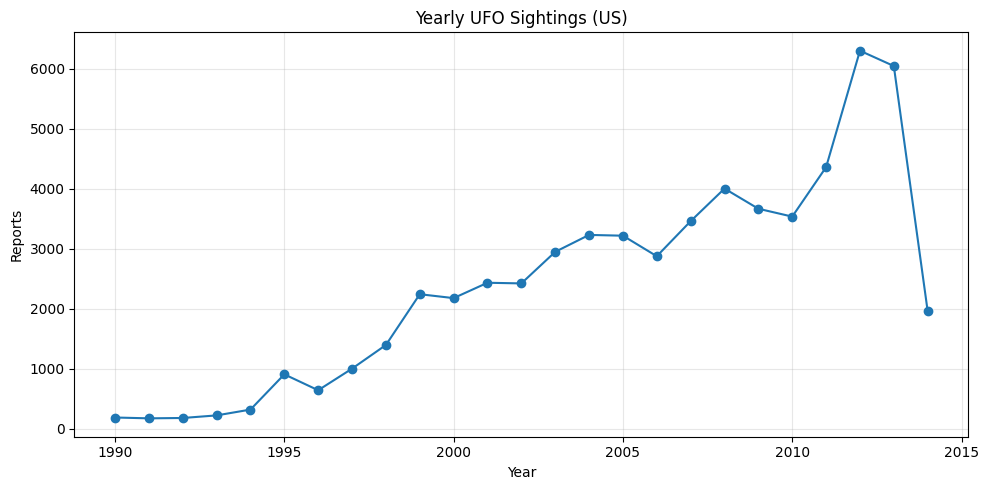

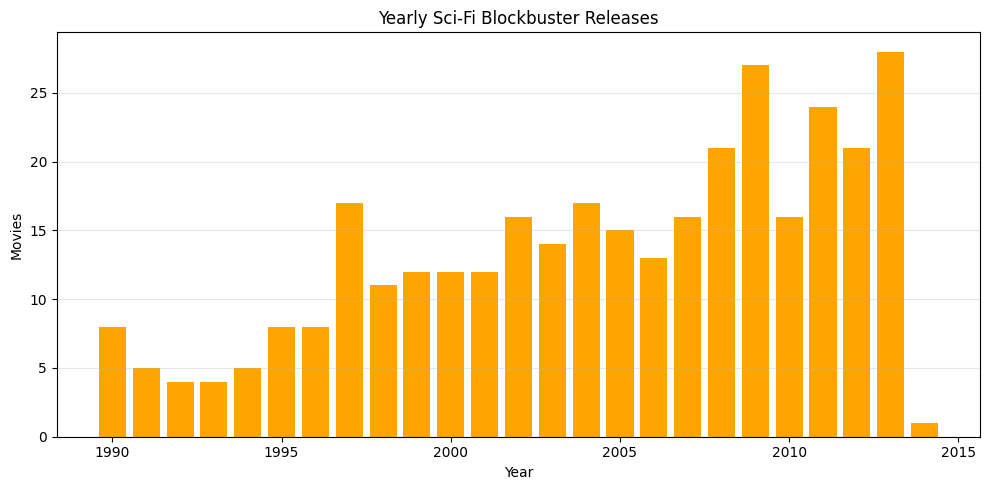

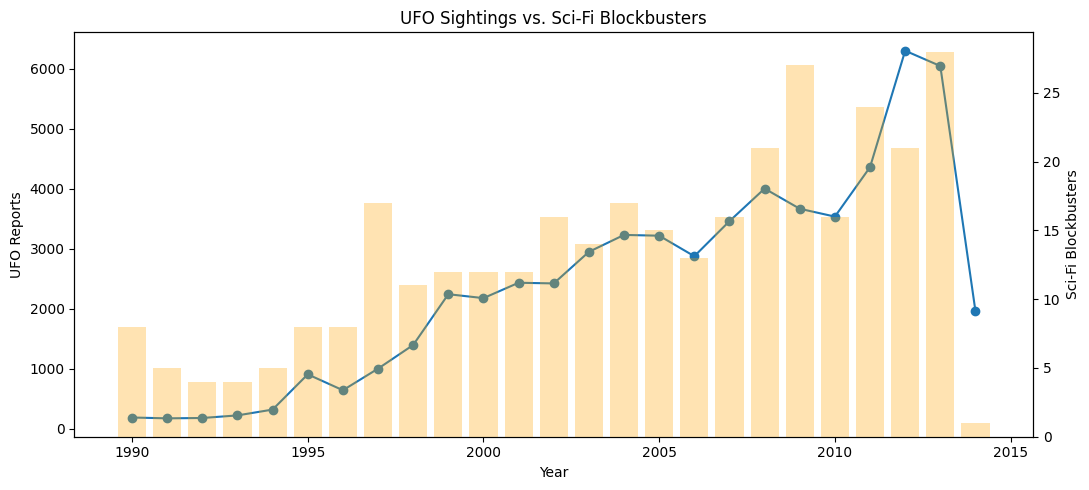

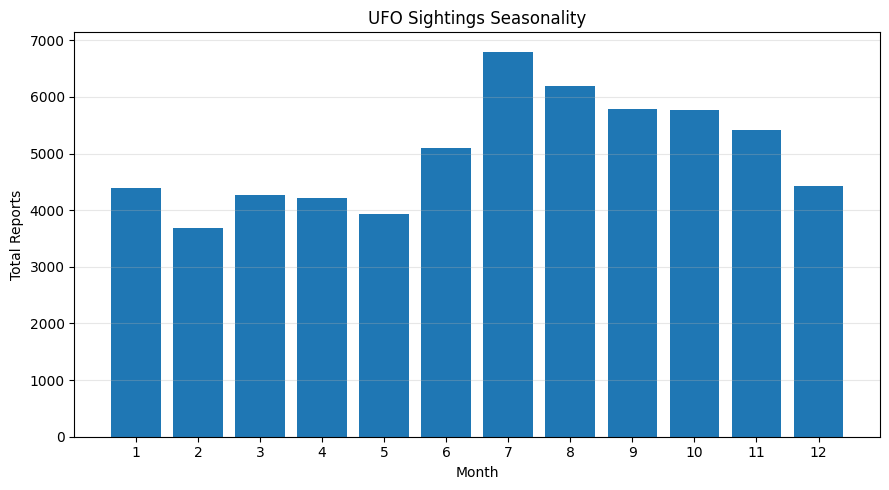

In [ ]:
# ============================
# STEP 4 - DESCRIPTIVE PLOTS
# ============================

# Ensure output folder exists
os.makedirs("figures", exist_ok=True)

# 1. Yearly UFO reports
ufo_by_year = ufo_clean.groupby("year").size().rename("ufo_reports").reset_index()

plt.figure(figsize=(10, 5))
plt.plot(ufo_by_year["year"], ufo_by_year["ufo_reports"], marker="o")
plt.title("Yearly UFO Sightings (US)")
plt.xlabel("Year")
plt.ylabel("Reports")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/01_ufo_reports_by_year.png", dpi=300)
plt.show()

# 2. Yearly Sci-Fi Blockbusters
blockbusters_by_year = blockbusters.groupby("year").size().rename("blockbusters").reset_index()

plt.figure(figsize=(10, 5))
plt.bar(blockbusters_by_year["year"], blockbusters_by_year["blockbusters"], color="orange")
plt.title("Yearly Sci-Fi Blockbuster Releases")
plt.xlabel("Year")
plt.ylabel("Movies")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/02_blockbusters_by_year.png", dpi=300)
plt.show()

# 3. Overlay (Dual Axis)
# Merge both to align years properly
merged_year = pd.merge(ufo_by_year, blockbusters_by_year, on="year", how="outer").fillna(0).sort_values("year")

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(merged_year["year"], merged_year["ufo_reports"], marker="o", label="UFOs")
ax1.set_xlabel("Year")
ax1.set_ylabel("UFO Reports")

ax2 = ax1.twinx()
ax2.bar(merged_year["year"], merged_year["blockbusters"], alpha=0.3, color="orange", label="Movies")
ax2.set_ylabel("Sci-Fi Blockbusters")

plt.title("UFO Sightings vs. Sci-Fi Blockbusters")
fig.tight_layout()
plt.savefig("figures/03_ufo_and_blockbusters_dual_axis.png", dpi=300)
plt.show()

# 4. UFO Seasonality (by month)
ufo_by_month = ufo_clean.groupby("month").size().rename("ufo_reports").reset_index()

plt.figure(figsize=(9, 5))
plt.bar(ufo_by_month["month"], ufo_by_month["ufo_reports"])
plt.title("UFO Sightings Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Reports")
plt.xticks(range(1, 13))
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/04_ufo_reports_by_month.png", dpi=300)
plt.show()

## **5. Windows Creation**

**Goal:** Define before/after time windows to count UFO sightings around each movie's release.

For each movie, we track sightings across two windows (testing both **30-day** and **90-day** periods):
- **Before:** `release_date - window_days` up to the day before release.
- **After:** `release_date` up to `release_date + window_days`.

We then compute the daily sighting rates:

$$\text{rate}_{before}=\frac{n_{before}}{T}$$

$$\text{rate}_{after}=\frac{n_{after}}{T}$$

*(where $T$ is the window size in days)*

In [ ]:
# =================================
# STEP 5 - BEFORE / AFTER WINDOWS
# ================================

def build_event_windows(movies_df, ufo_df, windows):
    rows = []

    for _, movie in movies_df.iterrows():
        release = pd.Timestamp(movie["release_date"]).floor("D")

        for w in windows:
            delta = pd.Timedelta(days=w)

            # Count sightings using direct boolean masking
            n_before = ((ufo_df["date"] >= release - delta) & (ufo_df["date"] < release)).sum()
            n_after = ((ufo_df["date"] >= release) & (ufo_df["date"] < release + delta)).sum()

            rows.append({
                "title": movie["title"],
                "release_date": release,
                "window_days": w,
                "n_before": n_before,
                "n_after": n_after,
                "rate_before": n_before / w,
                "rate_after": n_after / w,
                "rate_ratio": (n_after / n_before) if n_before > 0 else np.nan, # Simplified math
                "popularity": movie.get("popularity", np.nan),
                "vote_average": movie.get("vote_average", np.nan),
                "vote_count": movie.get("vote_count", np.nan)
            })

    return pd.DataFrame(rows)

event_windows = build_event_windows(blockbusters, ufo_clean, WINDOWS_DAYS)

display(event_windows.sort_values(["window_days", "release_date"]).head())

,title,release_date,window_days,n_before,n_after,rate_before,rate_after,rate_ratio,popularity,vote_average,vote_count
0,Tremors,1990-01-19,30,8,11,0.266667,0.366667,1.375000,4.0536,6.933,3500
2,Teenage Mutant Ninja Turtles,1990-03-30,30,7,5,0.233333,0.166667,0.714286,4.9931,6.700,1918
4,Back to the Future Part III,1990-05-25,30,8,31,0.266667,1.033333,3.875000,7.7378,7.490,11354
6,Total Recall,1990-06-01,30,8,32,0.266667,1.066667,4.000000,7.4158,7.300,6332
8,RoboCop 2,1990-06-22,30,31,38,1.033333,1.266667,1.225806,3.1746,6.029,2081


## **6. Bayesian Gamma-Poisson Model**

**Goal:** Use Bayesian inference to test if a sci-fi movie release statistically increases the UFO sighting rate.

**The Math:**
We model the number of sightings $Y$ over a $T$-day window using a Poisson distribution:
$$Y \sim \text{Poisson}(\lambda T)$$
*(where $\lambda$ is the unknown daily rate).*

By placing a Gamma prior on this rate ($\lambda \sim \text{Gamma}(\alpha, \beta)$ with $\beta$ as the *rate parameter*), conjugacy gives us a very clean analytical update:
$$\lambda_{posterior} \sim \text{Gamma}(\alpha + Y, \beta + T)$$

**Applying this to our timeline:**
- **Prior:** Built using sightings **before** the movie release.
- **Posterior:** Updated using sightings **after** the release.

From there, we can simulate these distributions (via Monte Carlo) to compute the exact metric that matters for our hypothesis: **$P(\lambda_{after} > \lambda_{before})$** (the probability that the daily sighting rate genuinely spiked post-release).

In [ ]:
# ==========================================
# STEP 6 - BAYESIAN GAMMA-POISSON INFERENCE
# ==========================================

def run_bayesian_inference(row, alpha0=ALPHA0, beta0=BETA0, n_sim=N_SIM):
    T = row["window_days"]
    n_before = row["n_before"]
    n_after = row["n_after"]

    # 1. Direct Comparison (A/B testing)
    alpha_before, beta_before = alpha0 + n_before, beta0 + T
    alpha_after, beta_after = alpha0 + n_after, beta0 + T

    sim_before = rng.gamma(shape=alpha_before, scale=1/beta_before, size=n_sim)
    sim_after = rng.gamma(shape=alpha_after, scale=1/beta_after, size=n_sim)

    p_after_greater = np.mean(sim_after > sim_before)
    ratio_samples = sim_after / sim_before

    # 2. Strict Bayesian Version (Prior = Before, Posterior = Before + After)
    alpha_post, beta_post = alpha_before + n_after, beta_before + T
    sim_post = rng.gamma(shape=alpha_post, scale=1/beta_post, size=n_sim)
    p_post_gt_prior = np.mean(sim_post > sim_before)

    return pd.Series({
        "p_after_gt_before": p_after_greater,
        "ratio_median": np.median(ratio_samples),
        "ratio_ci_low": np.quantile(ratio_samples, 0.025),
        "ratio_ci_high": np.quantile(ratio_samples, 0.975),
        "p_legacy_project_version": p_post_gt_prior
    })

# Apply inference to our dataset
bayes_results = event_windows.join(event_windows.apply(run_bayesian_inference, axis=1))


# Filter columns for a clean final display
cols_to_show = [
    "title", "release_date", "window_days",
    "n_before", "n_after", "rate_before", "rate_after", "rate_ratio",
    "p_after_gt_before", "ratio_median", "ratio_ci_low", "ratio_ci_high"
]

# Display the top results sorted by our main probability metric
display(
    bayes_results[cols_to_show]
    .sort_values(["window_days", "p_after_gt_before"], ascending=[True, False])
    .head(15)
)

,title,release_date,window_days,n_before,n_after,rate_before,rate_after,rate_ratio,p_after_gt_before,ratio_median,ratio_ci_low,ratio_ci_high
134,Cube,1998-09-11,30,110,190,3.666667,6.333333,1.727273,1.0,1.722633,1.366814,2.184717
170,Titan A.E.,2000-06-16,30,144,258,4.800000,8.600000,1.791667,1.0,1.786861,1.461203,2.197031
256,Hulk,2003-06-20,30,172,275,5.733333,9.166667,1.598837,1.0,1.596564,1.323402,1.933085
258,28 Days Later,2003-06-27,30,182,281,6.066667,9.366667,1.543956,1.0,1.540869,1.280265,1.859739
288,AVP: Alien vs. Predator,2004-08-13,30,256,393,8.533333,13.100000,1.535156,1.0,1.532873,1.309033,1.795105
314,The Adventures of Sharkboy and Lavagirl,2005-06-10,30,220,329,7.333333,10.966667,1.495455,1.0,1.493407,1.259943,1.776378
376,The Man from Earth,2007-06-10,30,197,362,6.566667,12.066667,1.837563,1.0,1.834475,1.543796,2.181870
378,Fantastic Four: Rise of the Silver Surfer,2007-06-15,30,204,379,6.800000,12.633333,1.857843,1.0,1.854988,1.567154,2.199878
434,Resident Evil: Degeneration,2008-12-30,30,233,357,7.766667,11.900000,1.532189,1.0,1.530705,1.299259,1.808044
538,Super 8,2011-06-09,30,229,534,7.633333,17.800000,2.331878,1.0,2.327740,1.997749,2.720784


## **7. Multivariable Visualisation**

**Goal:** Instead of cherry-picking a single movie, we visualize the aggregated shift across all blockbusters to capture the industry-wide trend.

This plot compares two global distributions:
- The **average baseline rate** across all movies (Before release).
- The **average updated rate** across all movies (After release).

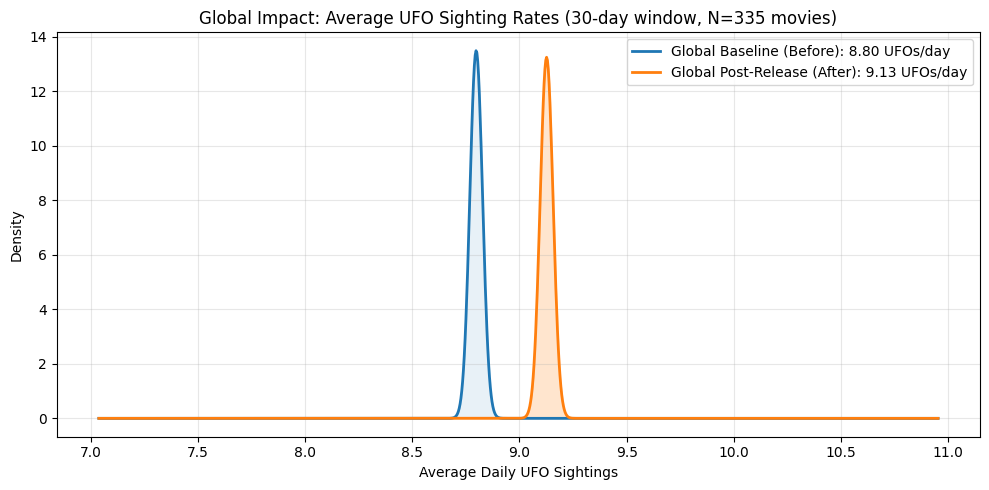

--- GLOBAL SUMMARY (30-DAY WINDOW) ---
Movies analyzed: 335
Total UFO sightings BEFORE: 88430
Total UFO sightings AFTER: 91730
Global P(Rate After > Rate Before): 1.0000


In [ ]:
# ======================================
# STEP 7 - GLOBAL IMPACT POSTERIOR PLOT
# ======================================

def plot_global_impact(df, window_days=30, alpha0=ALPHA0, beta0=BETA0):
    # Filter data for the requested window
    subset = df[df["window_days"] == window_days]
    n_movies = len(subset)

    # Pool all counts and time across all blockbusters
    total_n_before = subset["n_before"].sum()
    total_n_after = subset["n_after"].sum()
    total_T = subset["window_days"].sum() # Total days observed (movies * window)

    # Build Global Bayesian distributions
    alpha_before, beta_before = alpha0 + total_n_before, beta0 + total_T
    alpha_after, beta_after = alpha0 + total_n_after, beta0 + total_T

    # Calculate means for the plot limits
    mean_before = alpha_before / beta_before
    mean_after = alpha_after / beta_after

    # Set up x-axis dynamically based on our data
    x_min = min(mean_before, mean_after) * 0.8
    x_max = max(mean_before, mean_after) * 1.2
    x = np.linspace(max(0, x_min), x_max, 1000)

    # Generate Gamma PDFs
    pdf_before = gamma.pdf(x, a=alpha_before, scale=1/beta_before)
    pdf_after = gamma.pdf(x, a=alpha_after, scale=1/beta_after)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(x, pdf_before, label=f"Global Baseline (Before): {mean_before:.2f} UFOs/day", color="#1f77b4", linewidth=2)
    plt.plot(x, pdf_after, label=f"Global Post-Release (After): {mean_after:.2f} UFOs/day", color="#ff7f0e", linewidth=2)

    # Add some transparency fills for visual polish
    plt.fill_between(x, pdf_before, alpha=0.1, color="#1f77b4")
    plt.fill_between(x, pdf_after, alpha=0.2, color="#ff7f0e")

    plt.title(f"Global Impact: Average UFO Sighting Rates ({window_days}-day window, N={n_movies} movies)")
    plt.xlabel("Average Daily UFO Sightings")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"figures/05_global_impact_{window_days}d.png"
    plt.savefig(filename, dpi=300)
    plt.show()

    # Compute the global probability P(After > Before) using Monte Carlo
    sim_before = rng.gamma(shape=alpha_before, scale=1/beta_before, size=100000)
    sim_after = rng.gamma(shape=alpha_after, scale=1/beta_after, size=100000)
    p_global_increase = np.mean(sim_after > sim_before)

    # Print clean summary stats
    print(f"--- GLOBAL SUMMARY ({window_days}-DAY WINDOW) ---")
    print(f"Movies analyzed: {n_movies}")
    print(f"Total UFO sightings BEFORE: {int(total_n_before)}")
    print(f"Total UFO sightings AFTER: {int(total_n_after)}")
    print(f"Global P(Rate After > Rate Before): {p_global_increase:.4f}")

# Generate the plot for the 30-day window
plot_global_impact(bayes_results, window_days=30)